In [139]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [140]:
df=pd.read_csv("Customer-Churn-Records.csv")

In [141]:
df.drop("RowNumber",axis=1,inplace=True)

In [142]:
df.drop("Card Type",axis=1,inplace=True)

In [143]:
df.drop("Surname",axis=1,inplace=True)

In [144]:
df.drop("Geography",axis=1,inplace=True)

In [145]:
df.drop("Gender",axis=1,inplace=True)

In [146]:
df.drop("CustomerId",axis=1,inplace=True)

In [147]:
df['Exited'] = df['Exited'].map({0: 'No', 1: 'Yes'})

In [148]:
df


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
0,619,42,2,0.00,1,1,1,101348.88,Yes,1,2,464
1,608,41,1,83807.86,1,0,1,112542.58,No,1,3,456
2,502,42,8,159660.80,3,1,0,113931.57,Yes,1,3,377
3,699,39,1,0.00,2,0,0,93826.63,No,0,5,350
4,850,43,2,125510.82,1,1,1,79084.10,No,0,5,425
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,No,0,1,300
9996,516,35,10,57369.61,1,1,1,101699.77,No,0,5,771
9997,709,36,7,0.00,1,0,1,42085.58,Yes,1,3,564
9998,772,42,3,75075.31,2,1,0,92888.52,Yes,1,2,339


In [149]:
X=df.copy()


In [150]:
X.drop("Exited",axis=1,inplace=True)

In [151]:
y = df["Exited"]


In [152]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [153]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [154]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_Scaled,y_train)

LogisticRegression()

In [155]:
y_pred=model.predict(X_test)

c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [156]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [157]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8035

Confusion Matrix:
 [[1607    0]
 [ 393    0]]

Classification Report:
               precision    recall  f1-score   support

          No       0.80      1.00      0.89      1607
         Yes       0.00      0.00      0.00       393

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.80      0.72      2000



c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

LDA

In [158]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis(n_components=1)


In [170]:
X_train_lda=lda.fit_transform(X_train_Scaled,y_train)
X_test_lda=lda.transform(X_test_Scaled)

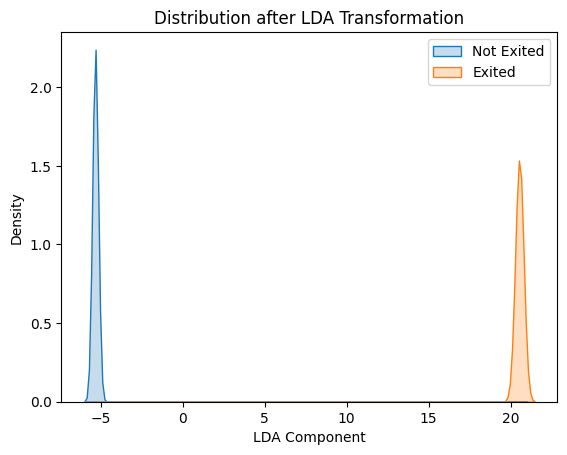

In [162]:
import seaborn as sns 



sns.kdeplot(X_train_lda[y_train=="No"][:,0], label="Not Exited", fill=True)
sns.kdeplot(X_train_lda[y_train=="Yes"][:,0], label="Exited", fill=True)

plt.xlabel("LDA Component")
plt.title("Distribution after LDA Transformation")
plt.legend()
plt.show()


In [164]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_lda,y_train)

LogisticRegression()

In [165]:
y_pred1=model.predict(X_test_lda)

In [166]:
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


Accuracy: 0.999

Confusion Matrix:
 [[1606    1]
 [   1  392]]

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00      1607
         Yes       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Infrences based on LDA and without lda

The model that did not use Linear Discriminant Analysis achieved an accuracy of 80 percent but when you look at the confusion matrix and the classification report you can see that it did a bad job of predicting the Exited class. In fact it got zero precision and recall for the Exited class. This means the model was really bad at predicting when customers exited. It was better at predicting customers who did not exit.

The model that used Linear Discriminant Analysis did a lot better. Its accuracy was 99 percent. This is an improvement from the model, without Linear Discriminant Analysis. The Linear Discriminant Analysis really helped the model predict the class correctly. The confusion matrix shows that both classes were classified correctly with almost perfect precision, recall, and F1-scores. LDA effectively reduced the dataset to a single component that maximized class separability, enabling the model to distinguish clearly between exited and non-exited customers. Thus, applying LDA greatly enhanced classification performance and overall model reliability.